# Pesta Data 2026 - Notebook v7 (revisi)
Dasarnya sama seperti v7 dari rekan tim, dengan 3 penyesuaian:

1. **Ditambah bagian 3.1** (bersihkan duplikat URL & noise batch scan tanggal 8/2/2024) sebelum audit_mislabel -- belum ada di v7 asli.
2. **`USE_TIME_FEATURES_FULL` dipaksa `False`.** Terbukti bocor: kelas `fakeshop` cuma muncul di 1 dari 185 `discovered_week`, jadi model bisa 'nyontek' lewat minggu batch pelaporan, bukan belajar isi URL. Skor X_val 0.97 yang didapat dengan saklar ini ON kemungkinan besar tidak akan tergeneralisasi ke data baru -- lihat penjelasan di bagian 5.
3. **Fitur baru: `USE_CATEGORY_KEYWORDS`** -- hitung kata kunci khas per kategori (`online_gambling`, `phishing` dari `audit_mislabel.KEYWORD_MAP`; `malware` dari analisis lift kata baru) sebagai fitur numerik langsung ke model, bukan cuma dipakai di audit label.

**Saklar yang tersedia:**

| Saklar | Default (revisi ini) | Efek |
|---|---|---|
| `USE_RELABEL` | `True` | Perbaikan label lewat `audit_mislabel` |
| `USE_DOMAIN_AGE` | `True` | Fitur `domain_age_days` (turunan `discovered - registration_date`). Proporsi negatif konsisten train (26%) vs predict (23.7%) -- aman |
| `USE_MIDNIGHT_FEATURE` | `True` | `is_midnight_exact`, penanda baris berjam persis 00:00 (indikasi kuat untuk `spam`, konsisten train vs predict) |
| `USE_CATEGORY_KEYWORDS` | `True` | `kw_online_gambling`, `kw_phishing`, `kw_malware`: hitungan kata khas per kategori |
| `USE_FAKESHOP_RULE` | `False` | `fakeshop_rule_hit`, aturan sempit hasil hafalan 5 sampel fakeshop -- TETAP MATI |
| `USE_TIME_FEATURES_FULL` | **`False` (dipaksa)** | `discovered_week` + `discovered_hour_cat` one-hot untuk SEMUA baris -- TERBUKTI BOCOR, jangan dinyalakan |

**Cara pakai:** ubah nilai di bagian 1.1, lalu **Run All** dari atas. Cell terakhir bagian 1.1 mencetak ringkasan saklar yang aktif.

## 1. Persiapan

In [1]:
%%time
import os
import re
import sys
import math
import warnings
from collections import Counter
from urllib.parse import urlparse, parse_qs, unquote

sys.path.insert(0, '../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import f1_score, make_scorer, classification_report, confusion_matrix
from scipy.stats import loguniform

from audit_mislabel import audit_mislabel, apply_relabel, summarize_audit, summarize_diff

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 90)
sns.set_theme(style='whitegrid')

CPU times: total: 2.62 s
Wall time: 6.49 s


### 1.1 Konfigurasi

Semua saklar eksperimen ada di sini. Ubah nilainya, lalu **Run All** dari atas notebook.


In [2]:
RANDOM_STATE = 42
VERSION = 'v7'

USE_RELABEL = True
RELABEL_THRESHOLD = 5
N_ITER_TUNING = 20

# --- turunan tanggal `discovered` (lihat tabel 'tingkat menghafal' di bagian judul) ---
USE_DOMAIN_AGE = True             # domain_age_days: aman, proporsi konsisten train(26%) vs predict(23.7%)
USE_MIDNIGHT_FEATURE = True       # is_midnight_exact: aman, sinyal kuat & konsisten untuk spam
USE_FAKESHOP_RULE = False         # fakeshop_rule_hit: HAFALAN dari 5 sampel, tetap mati
USE_TIME_FEATURES_FULL = False    # discovered_week/hour_cat one-hot: TERBUKTI BOCOR
                                   # (fakeshop cuma muncul di 1 dari 185 minggu -> model bisa 'nyontek'
                                   # lewat minggu, bukan belajar isi URL. Skor 0.97 di X_val kemarin
                                   # tidak akan tergeneralisasi ke data baru. WAJIB tetap False.)

# --- fitur baru: kata kunci per kategori (data-driven, dari analisis frekuensi kata) ---
USE_CATEGORY_KEYWORDS = True      # hitung jumlah kata khas online_gambling/phishing/malware di URL

CONFIDENCE_VALID_MIN = 0
CONFIDENCE_VALID_MAX = 100

RESULT_DIR = f'../../data/result/{VERSION}'
os.makedirs(RESULT_DIR, exist_ok=True)
np.random.seed(RANDOM_STATE)


In [3]:
# Ringkasan saklar yang aktif untuk run ini - dicetak supaya tidak lupa
# kombinasi mana yang sedang dicoba saat membandingkan hasil antar eksperimen.
_active = {
    'USE_RELABEL': USE_RELABEL,
    'USE_DOMAIN_AGE': USE_DOMAIN_AGE,
    'USE_MIDNIGHT_FEATURE': USE_MIDNIGHT_FEATURE,
    'USE_FAKESHOP_RULE': USE_FAKESHOP_RULE,
    'USE_TIME_FEATURES_FULL': USE_TIME_FEATURES_FULL,
    'USE_CATEGORY_KEYWORDS': USE_CATEGORY_KEYWORDS,
}
print(f'=== Konfigurasi aktif ({VERSION}) ===')
for k, v in _active.items():
    tanda = 'ON ' if v else 'off'
    print(f'  [{tanda}] {k}')
if USE_FAKESHOP_RULE and USE_TIME_FEATURES_FULL:
    print('\nCatatan: fakeshop_rule_hit dan discovered_week/hour_cat sama-sama aktif.')
    print('Keduanya bisa saling menangkap fakeshop lewat jalur berbeda -> sulit memisahkan kontribusi masing-masing.')
if USE_TIME_FEATURES_FULL:
    print('\nPERINGATAN: USE_TIME_FEATURES_FULL=True terbukti bocor (fakeshop cuma di 1/185 minggu).')
    print('Skor validasi akan terlihat sangat tinggi tapi TIDAK akan tergeneralisasi ke data baru.')


=== Konfigurasi aktif (v7) ===
  [ON ] USE_RELABEL
  [ON ] USE_DOMAIN_AGE
  [ON ] USE_MIDNIGHT_FEATURE
  [off] USE_FAKESHOP_RULE
  [off] USE_TIME_FEATURES_FULL
  [ON ] USE_CATEGORY_KEYWORDS


## 2. Ambil Data

In [4]:
train = pd.read_csv('training.csv')
test = pd.read_csv('predict.csv')
submission_template = pd.read_csv('submission-template.csv')

print(f"Dimensi Training : {train.shape}")
print(f"Dimensi Predict  : {test.shape}")
assert (test['id'].values == submission_template['id'].values).all(), 'Urutan id predict != template submission'
train.head(3)

Dimensi Training : (8400, 10)
Dimensi Predict  : (1500, 10)


,url,brand,discovered,confidence_level,ip,domain,sld,category,registrar,registration_date
0,https://lucah3.***********.my.id/,Telegram,5/1/2024 21:52,100,NaN,***********.my.id,my.id,phishingg,PT Web Media Technology Indonesia,5/14/2026
1,https://dpmptsp.*********.go.id/petapotensi/database/stores/?slot=slotnesia77,judi online,8/5/2024 20:41,100,103.162.68.84,*********.go.id,go.id,online gambling,Kementerian Komunikasi dan Informatika,5/11/2009
2,http://klikpad.bkpd.**************.go.id/klikpad/menu/home/SULTAN188/,-,6/14/2024 7:05,100,103.18.117.8,**************.go.id,go.id,online gambling,Kementerian Komunikasi dan Informatika,3/13/2008


## 3. Bersihkan Penulisan Category (TRAIN saja)
Hanya merapikan typo dan huruf besar/kecil. **Tidak ada penggabungan kategori**, semua 9 kelas resmi dipertahankan. Semua tulisan diubah ke huruf kecil dulu, lalu dipetakan. Kalau ada tulisan yang belum dikenal, kode berhenti dengan error supaya tidak ada label yang lolos diam-diam.

In [5]:
CATEGORY_MAP = {
    'online gambling': 'online gambling', 'online gamblingg': 'online gambling',
    'phishing': 'phishing', 'phishingg': 'phishing',
    'other': 'other', 'otherr': 'other',
    'spam': 'spam', 'spamm': 'spam',
    'malware': 'malware', 'malwaree': 'malware',
    'brand': 'brand',
    'fakeshop': 'fakeshop',
    'violence': 'violence',
    'piiexposure': 'piiexposure',
}
CANONICAL_CATEGORIES = sorted(set(CATEGORY_MAP.values()))


def normalize_category(x):
    key = str(x).strip().lower()
    if key not in CATEGORY_MAP:
        raise ValueError(f'Kategori tak dikenal: {x!r}')
    return CATEGORY_MAP[key]


train['category'] = train['category'].apply(normalize_category)

print(f'Jumlah kelas: {train["category"].nunique()} -> {CANONICAL_CATEGORIES}')
train['category'].value_counts()

Jumlah kelas: 9 -> ['brand', 'fakeshop', 'malware', 'online gambling', 'other', 'phishing', 'piiexposure', 'spam', 'violence']


category
online gambling    5447
phishing           2253
other               284
spam                185
malware             179
brand                45
fakeshop              5
violence              1
piiexposure           1
Name: count, dtype: int64

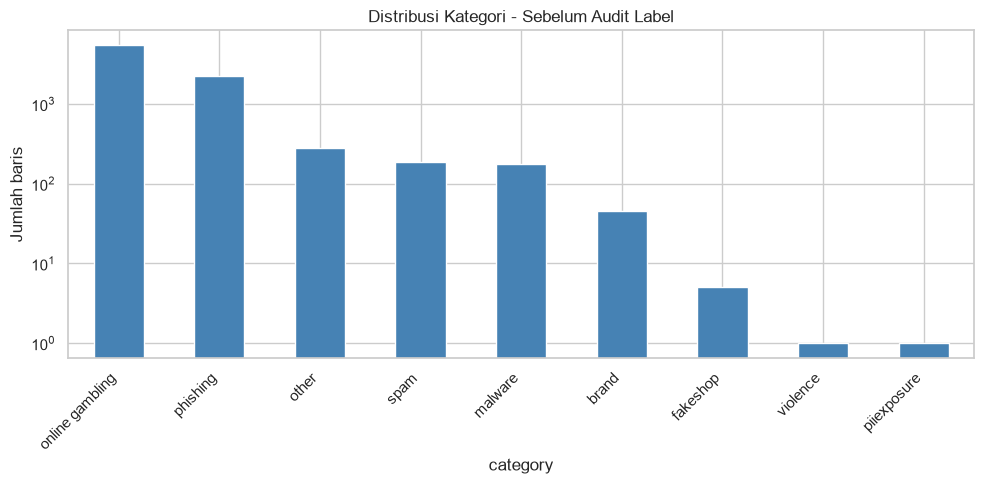

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
train['category'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribusi Kategori - Sebelum Audit Label')
ax.set_ylabel('Jumlah baris')
ax.set_yscale('log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.1 Bersihkan Duplikat URL & Noise Batch Scan

1. **Noise batch scan**: baris `other` bertanggal `8/2/2024` yang URL-nya juga punya label lain di baris lain -- kemungkinan besar hasil scan ulang massal yang di-default ke `other`. `other` yang cuma muncul sekali tanpa bukti apa pun TIDAK disentuh.
2. **URL dengan label bentrok**: sisakan satu baris per URL (yang paling baru `discovered`-nya).

Dilakukan sebelum audit_mislabel supaya audit bekerja di atas data yang sudah lebih bersih.

In [7]:
n_before_dedup = len(train)
train['_dt'] = pd.to_datetime(train['discovered'], format='%m/%d/%Y %H:%M', errors='coerce')

conflict_urls_check = train.groupby('url')['category'].nunique()
conflict_urls_check = set(conflict_urls_check[conflict_urls_check > 1].index)
is_batch_noise = (
    (train['_dt'].dt.date.astype(str) == '2024-08-02')
    & (train['category'] == 'other')
    & (train['url'].isin(conflict_urls_check))
)
print(f"Baris noise batch scan yang dibuang: {is_batch_noise.sum()}")
train = train[~is_batch_noise].reset_index(drop=True)

conflict_urls = train.groupby('url')['category'].nunique()
conflict_urls = conflict_urls[conflict_urls > 1].index
print(f"URL yang masih bentrok: {len(conflict_urls)}")
sub = train[train['url'].isin(conflict_urls)]
idx_keep = sub.sort_values('_dt').groupby('url').tail(1).index
idx_drop = sub.index.difference(idx_keep)
print(f"Baris duplikat lama yang dibuang: {len(idx_drop)}")
train = train.drop(index=idx_drop).drop(columns='_dt').reset_index(drop=True)
print(f"Total baris: {n_before_dedup} -> {len(train)}")
train['category'].value_counts()

Baris noise batch scan yang dibuang: 202
URL yang masih bentrok: 104
Baris duplikat lama yang dibuang: 250
Total baris: 8400 -> 7948


category
online gambling    5310
phishing           2209
malware             163
spam                143
other                75
brand                41
fakeshop              5
violence              1
piiexposure           1
Name: count, dtype: int64

## 4. Audit & Perbaiki Category (TRAIN saja, bukti url + ip)
Sama seperti v5. Label sebelum perbaikan disimpan di kolom `category_asli`. Kolom itu **tidak dipakai sebagai fitur**, hanya untuk membandingkan dan menguji dampak relabel di bagian 10.

In [8]:
category_asli = train['category'].reset_index(drop=True).values
n_before = len(train)

if USE_RELABEL:
    train_audited = audit_mislabel(train)
    summarize_audit(train_audited)
    train, diff_table = apply_relabel(train_audited, score_threshold=RELABEL_THRESHOLD)
    summarize_diff(diff_table)
    diff_table.to_csv(f'{RESULT_DIR}/relabel_diff.csv', index=False)
    print(f"\nCatatan perubahan label tersimpan di {RESULT_DIR}/relabel_diff.csv")
else:
    diff_table = None
    print('USE_RELABEL = False -> label dipakai apa adanya (setelah dirapikan).')

train = train.reset_index(drop=True)
assert len(train) == n_before, 'apply_relabel mengubah jumlah baris, cek audit_mislabel'
assert set(train['category']) <= set(CANONICAL_CATEGORIES), 'Ada kategori di luar 9 kelas resmi setelah relabel'

train['category_asli'] = category_asli
n_changed = int((train['category'] != train['category_asli']).sum())
print(f'\nBaris yang labelnya berubah: {n_changed}')

pd.DataFrame({
    'sebelum_relabel': train['category_asli'].value_counts(),
    'sesudah_relabel': train['category'].value_counts(),
}).fillna(0).astype(int)

=== Distribusi skor kecurigaan ===
suspect_score
11       1
8       13
6        1
5       20
4        9
3      119
2      107
1      150
0     7528
Name: count, dtype: int64

Skor >=5 (relabel otomatis)      : 35 baris
Skor 3-4 (verifikasi manual)     : 128 baris
Skor 1-2 (biarkan, terlalu lemah): 257 baris
=== Total baris yang benar-benar berubah label: 35 ===

=== Perubahan per pasangan (label lama -> label baru) ===
category_before  category_after 
phishing         online gambling    12
malware          online gambling     7
online gambling  phishing            5
other            online gambling     5
spam             online gambling     5
                 phishing            1
dtype: int64

Catatan perubahan label tersimpan di ../../data/result/v7/relabel_diff.csv

Baris yang labelnya berubah: 35


,sebelum_relabel,sesudah_relabel
online gambling,5310,5334
phishing,2209,2203
malware,163,156
spam,143,137
other,75,70
brand,41,41
fakeshop,5,5
violence,1,1
piiexposure,1,1


## 5. Feature Engineering

Fitur inti (selalu aktif, sama seperti v6):

1. **Bentuk URL** (numerik): panjang, kedalaman path, jumlah parameter, rasio angka, entropy karakter, `https`, `www`, dsb.
2. **Isi URL** (teks): TF-IDF kata dan karakter dari subdomain + path + query.
3. **Metadata** (kategori): `sld`, `brand`, `registrar`.
4. `confidence_level` dibersihkan: nilai di luar 0-100 (cuma ada di training) diisi median, ditandai `confidence_is_outlier`.

**Fitur turunan `discovered`, semuanya opsional lewat saklar di bagian 1.1:**

| Saklar | Fitur yang ditambahkan | Cakupan | Dasar |
|---|---|---|---|
| `USE_DOMAIN_AGE` | `domain_age_days`, `domain_age_is_negative` | Semua baris | Umum: domain baru lebih mencurigakan. Tapi tetap turunan tanggal `discovered` |
| `USE_MIDNIGHT_FEATURE` | `is_midnight_exact` | Semua baris | 89% `spam` di training berjam persis 00:00 vs <3% kelas lain; proporsinya sama di predict (2,8%). Indikasi format sumber data, bukan pola minggu |
| `USE_FAKESHOP_RULE` | `fakeshop_rule_hit` | ~8 baris di training yang cocok bentuk+tanggal | Hafalan eksplisit dari 5 sampel fakeshop (bentuk URL polos + jendela 26 Apr-1 Mei 2024). Presisi cuma 62,5% (5/8) |
| `USE_TIME_FEATURES_FULL` | `discovered_week`, `discovered_hour_cat` (one-hot) | **Semua baris**, semua kelas | Meniru eksp4. Tidak spesifik ke satu kelas, tapi berisiko menghafal pola batch pelaporan yang mungkin tidak berlaku di luar periode training |

**Kalau `USE_TIME_FEATURES_FULL = True`:** `discovered_week` dihitung dari `(discovered - 2020-01-01).days // 7`, lalu diubah ke string supaya di-one-hot (bukan numerik berurut). `discovered_hour_cat` adalah jam 0-23 sebagai string. Titik acuan 2020-01-01 dipilih karena beberapa hari sebelum baris `discovered` paling awal di data (8 Januari 2020).


In [9]:
def is_bare(u):
    u2 = re.sub(r'^https?://', '', str(u)).rstrip('/')
    return '/' not in u2 and '?' not in u2


def shannon_entropy(s):
    if not s:
        return 0.0
    counts = Counter(s)
    n = len(s)
    return -sum((c / n) * math.log2(c / n) for c in counts.values())


def parse_url_parts(raw_url):
    u = str(raw_url)
    if '://' not in u:
        u = 'http://' + u
    try:
        return urlparse(u)
    except Exception:
        return urlparse('http://')


def mask_and_subdomain(domain):
    labels = str(domain).split('.')
    mask_idx = next((i for i, lab in enumerate(labels) if re.fullmatch(r'\*+', lab)), None)
    if mask_idx is None:
        return '', 0, str(domain)
    subdomain = '.'.join(labels[:mask_idx])
    mask_len = len(labels[mask_idx])
    tld_suffix = '.'.join(labels[mask_idx + 1:])
    return subdomain, mask_len, tld_suffix


def digit_ratio(s):
    s = s or ''
    return sum(ch.isdigit() for ch in s) / len(s) if len(s) > 0 else 0.0


def special_char_count(s):
    s = s or ''
    return sum(not ch.isalnum() for ch in s)

In [10]:
def engineer_features(df_in):
    df = df_in.copy()

    parsed = df['url'].apply(parse_url_parts)
    df['_path'] = parsed.apply(lambda p: unquote(p.path or ''))
    df['_query'] = parsed.apply(lambda p: unquote(p.query or ''))
    df['_path_query'] = (df['_path'] + ' ' + df['_query']).str.strip()

    mask_info = df['domain'].apply(mask_and_subdomain)
    df['subdomain_prefix'] = mask_info.apply(lambda t: t[0]).astype(object)
    df['mask_len'] = mask_info.apply(lambda t: t[1]).astype(float)

    # --- bentuk URL
    raw_url = df['url'].astype(str)
    df['url_length'] = raw_url.str.len()
    df['path_length'] = df['_path'].str.len()
    df['path_depth'] = df['_path'].str.count('/')
    df['query_param_count'] = df['_query'].apply(lambda q: len(parse_qs(q)) if q else 0)
    df['has_query'] = (df['_query'].str.len() > 0).astype(int)
    df['digit_ratio'] = df['_path_query'].apply(digit_ratio)
    df['special_char_count'] = df['_path_query'].apply(special_char_count)
    df['hyphen_count'] = df['_path_query'].str.count('-')
    df['path_query_entropy'] = df['_path_query'].apply(shannon_entropy)
    df['has_scheme'] = raw_url.str.contains('://').astype(float)
    df['is_https'] = raw_url.str.startswith('https').astype(float)
    df['trailing_slash'] = raw_url.str.endswith('/').astype(float)
    df['has_www'] = raw_url.str.contains(r'www\.').astype(float)
    df['n_sub_labels'] = df['subdomain_prefix'].apply(lambda s: len(s.split('.')) if s else 0).astype(float)
    df['is_bare'] = raw_url.apply(is_bare).astype(float)

    # --- metadata
    df['has_ip'] = df['ip'].notna().astype(int)

    # confidence_level: nilai di luar CONFIDENCE_VALID_MIN..MAX dianggap tidak valid
    # (di training ada -20, 250, 1000; tidak pernah muncul di predict). Diisi median
    # dari nilai yang valid, bukan dibuang, supaya baris predict tidak hilang.
    conf_raw = df['confidence_level'].astype(float)
    conf_valid_mask = conf_raw.between(CONFIDENCE_VALID_MIN, CONFIDENCE_VALID_MAX)
    df['confidence_is_outlier'] = (~conf_valid_mask).astype(float)
    conf_median = conf_raw.where(conf_valid_mask).median()
    df['confidence_level'] = conf_raw.where(conf_valid_mask, conf_median)

    df['sld_clean'] = df['sld'].fillna('unknown').astype(object)

    # --- teks untuk TF-IDF (tanda *** dari masking dibuang)
    text_raw = df['subdomain_prefix'].astype(str) + ' ' + df['_path_query'].astype(str)
    text_raw = text_raw.str.replace(r'\*+', ' ', regex=True)
    df['url_text'] = text_raw.str.lower().str.strip().astype(object)

    # --- opsional: is_midnight_exact, penanda sumber data (bukan pengelompokan minggu/jam)
    if USE_MIDNIGHT_FEATURE:
        discovered_dt = pd.to_datetime(df['discovered'], format='%m/%d/%Y %H:%M', errors='coerce')
        df['is_midnight_exact'] = (
            (discovered_dt.dt.hour == 0) & (discovered_dt.dt.minute == 0)
        ).astype(float)

    # --- opsional: aturan sempit khusus fakeshop (hafalan dari 5 sampel, lihat bagian 5)
    if USE_FAKESHOP_RULE:
        discovered_dt = pd.to_datetime(df['discovered'], format='%m/%d/%Y %H:%M', errors='coerce')
        fakeshop_window = discovered_dt.between('2024-04-26', '2024-05-01 23:59:59')
        is_form = (
            df['is_bare'].astype(bool)
            & ~raw_url.str.startswith('https')
            & (df['brand'].isna() | df['brand'].astype(str).str.strip().eq('-'))
        )
        df['fakeshop_rule_hit'] = (fakeshop_window & is_form).astype(float)

    # --- opsional: umur domain (turunan tanggal discovered, default mati)
    if USE_DOMAIN_AGE:
        discovered_dt = pd.to_datetime(df['discovered'], format='%m/%d/%Y %H:%M', errors='coerce')
        reg_dt = pd.to_datetime(df['registration_date'], format='%m/%d/%Y', errors='coerce')
        df['domain_age_days'] = (discovered_dt - reg_dt).dt.days.astype(float)
        df['domain_age_is_negative'] = (df['domain_age_days'] < 0).astype(float)

    # --- opsional: kata kunci khas per kategori (data-driven, dari analisis frekuensi kata
    # url_text pada training). online_gambling & phishing diambil dari KEYWORD_MAP yang sama
    # dengan audit_mislabel.py. malware dicari terpisah lewat analisis lift kata (lihat catatan
    # di bagian 5). spam SENGAJA tidak dikasih kata kunci -- dicoba dicari tapi tidak ada kata
    # yang punya lift meyakinkan; sinyal spam yang kuat sudah tertangkap is_midnight_exact.
    if USE_CATEGORY_KEYWORDS:
        KEYWORD_MAP_MODEL = {
            'kw_online_gambling': ['slot', 'gacor', 'judi', 'togel', 'toto', 'poker', 'rtp', 'depo'],
            'kw_phishing': ['verify', 'login', 'account', 'secure-', 'confirm-account'],
            'kw_malware': ['repository', 'statics', 'gudangsoal', 'popup', 'files', 'themes', 'assets', 'magnific'],
        }
        text_lower = df['url_text'].astype(str)
        for col, kws in KEYWORD_MAP_MODEL.items():
            pattern = '|'.join(kws)
            df[col] = text_lower.str.count(pattern)

    # --- opsional: discovered_week + discovered_hour_cat sebagai kategori (gaya eksp4)
    # Beda dari fitur lain di atas: ini one-hot per minggu/jam untuk SEMUA baris,
    # bukan penanda tunggal. Cakupannya jauh lebih luas, risiko menghafal pola batch
    # pelaporan juga lebih besar. Lihat bagian 5 untuk penjelasan lengkap.
    if USE_TIME_FEATURES_FULL:
        discovered_dt = pd.to_datetime(df['discovered'], format='%m/%d/%Y %H:%M', errors='coerce')
        discovered_ord = (discovered_dt - pd.Timestamp('2020-01-01')).dt.days
        df['discovered_week'] = discovered_ord.floordiv(7).astype('Int64').astype(str)
        df['discovered_hour_cat'] = discovered_dt.dt.hour.astype('Int64').astype(str)

    return df


NUMERIC_FEATURES = [
    'url_length', 'path_length', 'path_depth', 'query_param_count', 'has_query',
    'digit_ratio', 'special_char_count', 'hyphen_count', 'path_query_entropy',
    'mask_len', 'has_ip', 'confidence_level', 'confidence_is_outlier',
    'has_scheme', 'is_https', 'trailing_slash', 'has_www', 'n_sub_labels', 'is_bare',
]
if USE_MIDNIGHT_FEATURE:
    NUMERIC_FEATURES += ['is_midnight_exact']
if USE_FAKESHOP_RULE:
    NUMERIC_FEATURES += ['fakeshop_rule_hit']
if USE_DOMAIN_AGE:
    NUMERIC_FEATURES += ['domain_age_days', 'domain_age_is_negative']
if USE_CATEGORY_KEYWORDS:
    NUMERIC_FEATURES += ['kw_online_gambling', 'kw_phishing', 'kw_malware']

CATEGORICAL_FEATURES = ['sld_clean', 'brand_clean', 'registrar_clean']
if USE_TIME_FEATURES_FULL:
    CATEGORICAL_FEATURES += ['discovered_week', 'discovered_hour_cat']

TEXT_FEATURE = 'url_text'

### 5.1 Jalankan ke train dan predict, lalu kelompokkan brand/registrar yang jarang

Frekuensi dihitung **hanya dari data train**, lalu dipakai apa adanya ke data predict.

In [11]:
def clean_brand_series(s):
    s = s.fillna('unknown').astype(str).str.strip().str.lower()
    return s.replace({'-': 'unknown'})


def clean_registrar_series(s):
    return s.fillna('unknown').astype(str).str.strip().str.lower()


def build_keep_set(series, min_count):
    counts = series.value_counts()
    return set(counts[counts >= min_count].index)


def apply_bucket(series, keep_set, bucket_name):
    return series.where(series.isin(keep_set), bucket_name).astype(object)


train_feat = engineer_features(train)
predict_feat = engineer_features(test)

brand_train = clean_brand_series(train_feat['brand'])
registrar_train = clean_registrar_series(train_feat['registrar'])
brand_keep = build_keep_set(brand_train, min_count=5)
registrar_keep = build_keep_set(registrar_train, min_count=10)

train_feat['brand_clean'] = apply_bucket(brand_train, brand_keep, 'rare_brand')
train_feat['registrar_clean'] = apply_bucket(registrar_train, registrar_keep, 'other_registrar')
predict_feat['brand_clean'] = apply_bucket(clean_brand_series(predict_feat['brand']), brand_keep, 'rare_brand')
predict_feat['registrar_clean'] = apply_bucket(clean_registrar_series(predict_feat['registrar']), registrar_keep, 'other_registrar')

used_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TEXT_FEATURE]
time_cols_used = [c for c in used_cols if c.startswith('discovered')]
if not USE_TIME_FEATURES_FULL:
    assert not time_cols_used, 'Ada fitur discovered_week/hour_cat yang lolos padahal togglenya mati'

print(f'Fitur numerik: {len(NUMERIC_FEATURES)} | kategorikal: {len(CATEGORICAL_FEATURES)} | teks: 1')
print('Fitur discovered_week/discovered_hour_cat (one-hot, gaya eksp4):', 'AKTIF' if time_cols_used else 'tidak dipakai')
train_feat[used_cols].head()

Fitur numerik: 25 | kategorikal: 3 | teks: 1
Fitur discovered_week/discovered_hour_cat (one-hot, gaya eksp4): tidak dipakai


,url_length,path_length,path_depth,query_param_count,has_query,digit_ratio,special_char_count,hyphen_count,path_query_entropy,mask_len,has_ip,confidence_level,confidence_is_outlier,has_scheme,is_https,trailing_slash,has_www,n_sub_labels,is_bare,is_midnight_exact,domain_age_days,domain_age_is_negative,kw_online_gambling,kw_phishing,kw_malware,sld_clean,brand_clean,registrar_clean,url_text
0,33,1,1,0,0,0.000000,1,0,-0.000000,11.0,0,100.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,-743.0,1.0,0,0,0,my.id,telegram,pt web media technology indonesia,/
1,77,29,4,1,1,0.043478,6,0,3.689202,9.0,1,100.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,5565.0,0.0,2,0,0,go.id,judi online,kementerian komunikasi dan informatika,/petapotensi/database/stores/ slot=slotnesia77
2,69,29,5,0,0,0.103448,5,0,4.181786,14.0,1,100.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,5937.0,0.0,0,0,0,go.id,unknown,kementerian komunikasi dan informatika,/klikpad/menu/home/sultan188/
3,76,12,3,1,1,0.038462,5,0,3.950064,20.0,1,100.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,5486.0,0.0,0,0,0,go.id,unknown,kementerian komunikasi dan informatika,/public/svg/ google=toko4d
4,94,22,4,1,1,0.000000,12,1,4.660022,10.0,1,100.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4587.0,0.0,2,0,0,go.id,unknown,kementerian komunikasi dan informatika,/e-koor/storage/nenen/ listing=slot+gacor+hari+ini+dan+polanya


## 6. Membagi Data Latih dan Validasi

Semua 9 kelas ikut, termasuk `violence` dan `piiexposure` yang hanya 1 sampel. Pembagian memakai `StratifiedGroupKFold` dengan `url` sebagai group, jadi URL yang sama tidak mungkin muncul di train dan validasi sekaligus. Satu fold (20%) jadi hold-out, sisanya untuk screening dan tuning.

**Macro-F1 yang dipakai** meniru aturan panitia: rata-rata hanya dari kelas yang benar-benar ada di `y_true`. Kalau suatu fold tidak punya contoh `fakeshop`, kelas itu tidak dihitung di fold tersebut. Tapi kalau ada dan salah diprediksi, skornya 0 dan menurunkan rata-rata.

`MAIN_LABELS` (kelas dengan minimal 20 contoh) ditampilkan sebagai pembanding tambahan, karena satu contoh `fakeshop`, `violence`, atau `piiexposure` bisa menggeser skor semua-kelas cukup jauh.

In [12]:
X_cv = train_feat.reset_index(drop=True)
y_cv = X_cv['category']
groups_cv = X_cv['url'].values

class_counts = y_cv.value_counts()
MAIN_LABELS = sorted(c for c in class_counts.index if class_counts[c] >= 20)

group_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, val_idx = next(group_cv.split(X_cv, y_cv, groups_cv))
X_train, X_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
y_train, y_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]
groups_train = X_train['url'].values
val_labels = sorted(y_val.unique())


def macro_f1_present(y_true, y_pred):
    labels = sorted(set(y_true))
    return f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)


def macro_f1_main(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=MAIN_LABELS, average='macro', zero_division=0)


def per_class_f1(y_true, y_pred, labels):
    scores = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    return dict(zip(labels, scores))


present_scorer = make_scorer(macro_f1_present)

train_counts = y_train.value_counts()
balanced_weights = len(y_train) / (len(train_counts) * train_counts)
soft_weights = np.sqrt(balanced_weights).to_dict()

print('X_train:', X_train.shape, '| X_val:', X_val.shape)
print('Kelas utama (>=20 contoh):', MAIN_LABELS)
print('Kelas di X_val:', val_labels)
print('URL yang sama di train dan val:', len(set(X_train['url']) & set(X_val['url'])))
class_counts

d:\rdhiy\python-env\my_global_env\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


X_train: (6341, 57) | X_val: (1607, 57)
Kelas utama (>=20 contoh): ['brand', 'malware', 'online gambling', 'other', 'phishing', 'spam']
Kelas di X_val: ['brand', 'fakeshop', 'malware', 'online gambling', 'other', 'phishing', 'spam']
URL yang sama di train dan val: 0


category
online gambling    5334
phishing           2203
malware             156
spam                137
other                70
brand                41
fakeshop              5
violence              1
piiexposure           1
Name: count, dtype: int64

## 7. Screening Model Kandidat

Tiga kandidat: Logistic Regression dan Linear SVC (linear, cocok untuk teks TF-IDF yang sparse), serta Random Forest (berbasis pohon). Preprocessor sama untuk semuanya, yang beda hanya classifier di ujung pipeline.

Fitur numerik diproses dengan median imputer, `RobustScaler`, lalu `clip` ke rentang -5 sampai 5 supaya nilai ekstrem (misalnya `confidence_level`) tidak mengganggu model linear.

In [13]:
def clip_scaled(X):
    return np.clip(X, -5, 5)


def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('tfidf_word', TfidfVectorizer(
                analyzer='word', ngram_range=(1, 2), min_df=2, max_features=3000,
                sublinear_tf=True), TEXT_FEATURE),
            ('tfidf_char', TfidfVectorizer(
                analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_features=3000,
                sublinear_tf=True), TEXT_FEATURE),
            ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler()),
                ('clip', FunctionTransformer(clip_scaled)),
            ]), NUMERIC_FEATURES),
        ],
        sparse_threshold=0.3,
    )


def build_pipeline(clf):
    return Pipeline([('features', build_preprocessor()), ('clf', clf)])


CANDIDATE_MODELS = {
    'logistic_regression': lambda: LogisticRegression(
        max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    'linear_svc': lambda: LinearSVC(
        class_weight='balanced', random_state=RANDOM_STATE, max_iter=5000),
    'random_forest': lambda: RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1),
}

In [14]:
screening_results = []
for name, factory in CANDIDATE_MODELS.items():
    pipe = build_pipeline(factory())
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    row = {
        'model': name,
        'macro_f1_main': macro_f1_main(y_val, pred),
        'macro_f1_val': macro_f1_present(y_val, pred),
    }
    row.update(per_class_f1(y_val, pred, ['malware', 'spam', 'brand']))
    row['fakeshop_hit'] = int(((y_val == 'fakeshop').values & (pred == 'fakeshop')).sum())
    screening_results.append(row)

screening_df = pd.DataFrame(screening_results).sort_values('macro_f1_val', ascending=False)
screening_df

,model,macro_f1_main,macro_f1_val,malware,spam,brand,fakeshop_hit
1,linear_svc,0.917842,0.786722,0.866667,0.877193,0.842105,0
0,logistic_regression,0.913583,0.783071,0.767123,0.912281,0.888889,0
2,random_forest,0.894922,0.767076,0.857143,0.905660,1.000000,0


Dua kandidat dengan `macro_f1_val` tertinggi dibawa ke tuning. Kalau urutan `macro_f1_val` dan `macro_f1_main` berbeda jauh, kemungkinan besar penyebabnya satu contoh `fakeshop`, bukan perbedaan kualitas model sebenarnya.

In [15]:
TOP_N_CANDIDATES = 2
top_candidates = screening_df['model'].head(TOP_N_CANDIDATES).tolist()
top_candidates

['linear_svc', 'logistic_regression']

## 8. Hyperparameter Tuning (RandomizedSearchCV)

Hyperparameter adalah pengaturan model yang ditentukan **sebelum** training (misalnya `C`, `class_weight`, `max_features` TF-IDF). `RandomizedSearchCV` mengambil `N_ITER_TUNING` kombinasi acak dari rentang di bawah, menilai tiap kombinasi dengan 5-fold group CV memakai macro-F1, lalu melatih ulang model dengan kombinasi terbaik.

`class_weight` ikut dicari. Selain `balanced` dan `None`, ada `soft_weights` (akar dari bobot balanced) karena bobot balanced penuh bisa membuat model terlalu sering menebak kelas kecil.

Tuning hanya memakai `X_train`; `X_val` tidak tersentuh, jadi tetap jadi hold-out yang jujur.

In [16]:
tuning_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

PARAM_DISTRIBUTIONS = {
    'logistic_regression': {
        'clf__C': loguniform(1e-2, 1e2),
        'clf__class_weight': ['balanced', None, soft_weights],
        'features__tfidf_word__max_features': [1000, 2000, 3000, 5000],
        'features__tfidf_word__min_df': [1, 2, 3],
        'features__tfidf_char__max_features': [1000, 2000, 3000, 5000],
    },
    'linear_svc': {
        'clf__C': loguniform(1e-2, 1e2),
        'clf__loss': ['hinge', 'squared_hinge'],
        'clf__class_weight': ['balanced', None, soft_weights],
        'features__tfidf_word__max_features': [1000, 2000, 3000, 5000],
        'features__tfidf_word__min_df': [1, 2, 3],
        'features__tfidf_char__max_features': [1000, 2000, 3000, 5000],
    },
    'random_forest': {
        'clf__n_estimators': [200, 300, 500],
        'clf__max_depth': [None, 20, 40, 60],
        'clf__min_samples_leaf': [1, 2, 4],
        'clf__max_features': ['sqrt', 'log2'],
        'clf__class_weight': ['balanced_subsample', 'balanced', None, soft_weights],
        'features__tfidf_word__max_features': [1000, 2000, 3000],
        'features__tfidf_char__max_features': [1000, 2000, 3000],
    },
}

In [17]:
tuned_searches = {}
for name in top_candidates:
    print(f'Tuning {name}...')
    search = RandomizedSearchCV(
        build_pipeline(CANDIDATE_MODELS[name]()),
        param_distributions=PARAM_DISTRIBUTIONS[name],
        n_iter=N_ITER_TUNING,
        scoring=present_scorer,
        cv=tuning_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train, groups=groups_train)
    tuned_searches[name] = search
    print(f'  macro-F1 CV terbaik: {search.best_score_:.4f}')

Tuning linear_svc...


d:\rdhiy\python-env\my_global_env\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  macro-F1 CV terbaik: 0.7574
Tuning logistic_regression...


d:\rdhiy\python-env\my_global_env\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  macro-F1 CV terbaik: 0.7536


### 8.1 Memilih model final

Pemilihan memakai prediksi out-of-fold (OOF) di `X_train`, diurutkan berdasarkan macro-F1 semua kelas. Hasil `fakeshop` (TP, FP, FN) ditampilkan di sebelahnya supaya kelihatan kalau urutan ditentukan oleh kelas yang sangat kecil itu.

In [18]:
selection_rows = []
for name in top_candidates:
    tuned_estimator = clone(tuned_searches[name].best_estimator_)
    sel_pred = cross_val_predict(
        tuned_estimator, X_train, y_train, cv=tuning_cv, groups=groups_train, n_jobs=-1)
    fs_true = (y_train == 'fakeshop').values
    fs_pred = sel_pred == 'fakeshop'
    row = {
        'model': name,
        'cv_tuning_semua_kelas': tuned_searches[name].best_score_,
        'oof_macro_semua_kelas': macro_f1_present(y_train, sel_pred),
        'oof_macro_kelas_utama': macro_f1_main(y_train, sel_pred),
    }
    row.update(per_class_f1(y_train, sel_pred, ['malware', 'spam', 'brand']))
    row['fakeshop_TP'] = int((fs_true & fs_pred).sum())
    row['fakeshop_FP'] = int((~fs_true & fs_pred).sum())
    row['fakeshop_FN'] = int((fs_true & ~fs_pred).sum())
    selection_rows.append(row)

comparison_df = pd.DataFrame(selection_rows).sort_values('oof_macro_semua_kelas', ascending=False)
display(comparison_df)

final_model_name = comparison_df.iloc[0]['model']
final_search = tuned_searches[final_model_name]
print('Model final yang dipilih:', final_model_name)
final_search.best_params_

d:\rdhiy\python-env\my_global_env\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
d:\rdhiy\python-env\my_global_env\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,model,cv_tuning_semua_kelas,oof_macro_semua_kelas,oof_macro_kelas_utama,malware,spam,brand,fakeshop_TP,fakeshop_FP,fakeshop_FN
1,logistic_regression,0.753638,0.606016,0.909023,0.880342,0.902326,0.911765,0,1,4
0,linear_svc,0.757434,0.601623,0.902434,0.896552,0.927273,0.927536,0,0,4


Model final yang dipilih: logistic_regression


{'clf__C': np.float64(2.440060709081755),
 'clf__class_weight': None,
 'features__tfidf_char__max_features': 3000,
 'features__tfidf_word__max_features': 3000,
 'features__tfidf_word__min_df': 3}

## 9. Evaluasi Model Final

### 9.1 Hold-out (X_val)

In [19]:
best_pipeline = build_pipeline(CANDIDATE_MODELS[final_model_name]())
best_pipeline.set_params(**final_search.best_params_)
best_pipeline.fit(X_train, y_train)

y_val_pred = best_pipeline.predict(X_val)
print(f'Macro-F1 di X_val (kelas yang ada di y_true): {macro_f1_present(y_val, y_val_pred):.4f}')
print(f'Macro-F1 kelas utama                        : {macro_f1_main(y_val, y_val_pred):.4f}')
print()
print(classification_report(y_val, y_val_pred, labels=val_labels, zero_division=0))

Macro-F1 di X_val (kelas yang ada di y_true): 0.7909
Macro-F1 kelas utama                        : 0.9227

                 precision    recall  f1-score   support

          brand       0.80      1.00      0.89         8
       fakeshop       0.00      0.00      0.00         1
        malware       0.96      0.81      0.88        31
online gambling       0.98      0.99      0.99      1066
          other       0.97      0.85      0.91        34
       phishing       0.98      0.97      0.97       440
           spam       0.92      0.89      0.91        27

       accuracy                           0.98      1607
      macro avg       0.80      0.79      0.79      1607
   weighted avg       0.98      0.98      0.98      1607



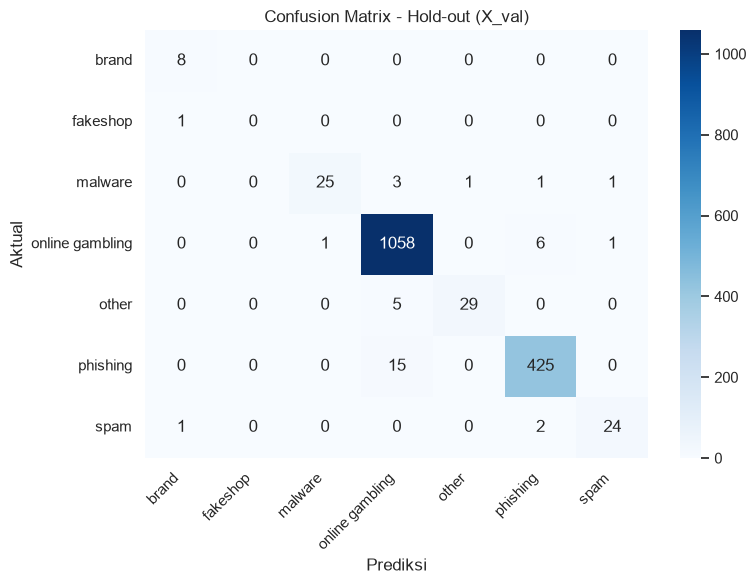

In [20]:
cm = confusion_matrix(y_val, y_val_pred, labels=val_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_labels, yticklabels=val_labels)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Hold-out (X_val)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 9.2 Group Cross Validation (seluruh data)

Prediksi out-of-fold dari semua fold digabung, lalu classification report gabungan dipakai sebagai angka utama. Rata-rata per fold tercampur dua artefak: fold yang memegang `violence` atau `piiexposure` pasti bernilai 0 untuk kelas itu, dan `fakeshop` yang hanya 5 contoh membuat skor naik turun.

In [21]:
final_pipeline_template = build_pipeline(CANDIDATE_MODELS[final_model_name]())
final_pipeline_template.set_params(**final_search.best_params_)

oof_pred = cross_val_predict(
    final_pipeline_template, X_cv, y_cv, cv=group_cv, groups=groups_cv, n_jobs=-1)

print(f'Macro-F1 OOF kelas utama : {macro_f1_main(y_cv, oof_pred):.4f}')
print(f'Macro-F1 OOF semua kelas : {macro_f1_present(y_cv, oof_pred):.4f}')
print()
print(classification_report(y_cv, oof_pred, zero_division=0))

d:\rdhiy\python-env\my_global_env\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Macro-F1 OOF kelas utama : 0.9194
Macro-F1 OOF semua kelas : 0.6129

                 precision    recall  f1-score   support

          brand       0.87      0.95      0.91        41
       fakeshop       0.00      0.00      0.00         5
        malware       0.95      0.80      0.87       156
online gambling       0.99      0.99      0.99      5334
          other       0.84      0.87      0.85        70
       phishing       0.98      0.98      0.98      2203
    piiexposure       0.00      0.00      0.00         1
           spam       0.93      0.90      0.91       137
       violence       0.00      0.00      0.00         1

       accuracy                           0.98      7948
      macro avg       0.62      0.61      0.61      7948
   weighted avg       0.98      0.98      0.98      7948



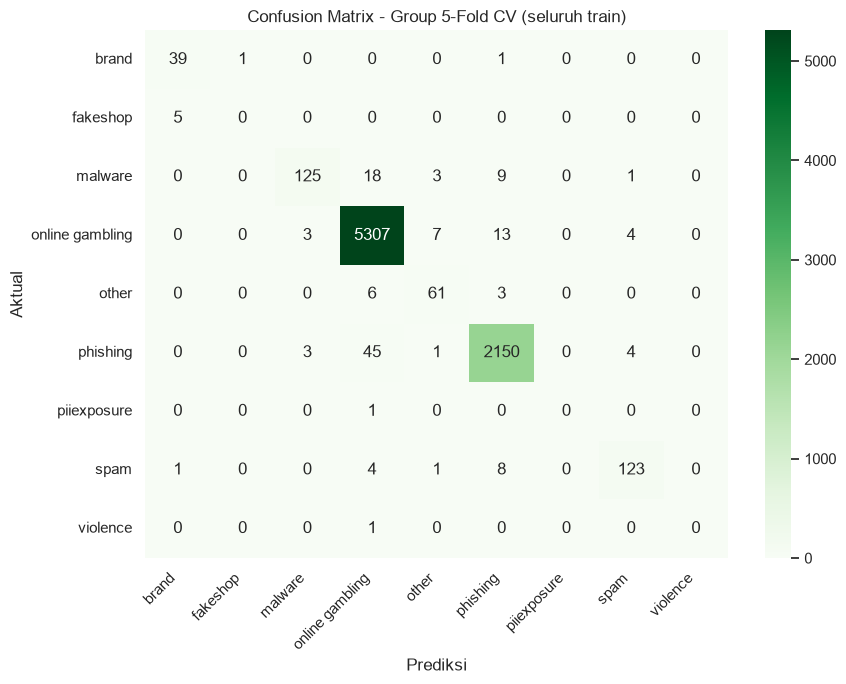

In [22]:
labels_cv = sorted(y_cv.unique())
cm_cv = confusion_matrix(y_cv, oof_pred, labels=labels_cv)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Greens', xticklabels=labels_cv, yticklabels=labels_cv)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Group 5-Fold CV (seluruh train)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 9.3 Repeated group CV (3 seed)

Satu seed bisa kebetulan bagus atau jelek. Standar deviasi antar seed menunjukkan seberapa besar noise dari cara membagi fold. Ekspektasi yang wajar: `std` kecil untuk kelas besar, dan besar untuk `fakeshop`.

In [23]:
repeat_rows = []
for seed in [42, 43, 44]:
    seed_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    seed_pred = cross_val_predict(
        final_pipeline_template, X_cv, y_cv, cv=seed_cv, groups=groups_cv, n_jobs=-1)
    row = {
        'seed': seed,
        'macro_f1_kelas_utama': macro_f1_main(y_cv, seed_pred),
        'macro_f1_semua_kelas': macro_f1_present(y_cv, seed_pred),
    }
    row.update(per_class_f1(y_cv, seed_pred, ['malware', 'spam', 'brand', 'other', 'fakeshop']))
    repeat_rows.append(row)

repeat_df = pd.DataFrame(repeat_rows)
display(repeat_df.round(4))
repeat_df.drop(columns='seed').agg(['mean', 'std']).round(4)

d:\rdhiy\python-env\my_global_env\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
d:\rdhiy\python-env\my_global_env\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
d:\rdhiy\python-env\my_global_env\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,seed,macro_f1_kelas_utama,macro_f1_semua_kelas,malware,spam,brand,other,fakeshop
0,42,0.9194,0.6129,0.8711,0.9145,0.907,0.8531,0.0
1,43,0.9033,0.6022,0.8720,0.9084,0.907,0.7656,0.0
2,44,0.9139,0.6092,0.8844,0.9104,0.907,0.8154,0.0


,macro_f1_kelas_utama,macro_f1_semua_kelas,malware,spam,brand,other,fakeshop
mean,0.9122,0.6081,0.8758,0.9111,0.907,0.8114,0.0
std,0.0082,0.0054,0.0074,0.0031,0.000,0.0439,0.0


### 9.4 Analisis error

Kolom `url_konflik` menandai URL yang muncul dengan label berbeda di data. Error di situ sulit dihindari oleh model apa pun, dan bisa jadi kandidat untuk diperiksa manual (mungkin noise label yang belum tertangkap `audit_mislabel`).

In [24]:
error_df = X_cv[['url', 'brand', 'registrar_clean']].assign(aktual=y_cv.values, prediksi=oof_pred)
error_df = error_df[error_df['aktual'] != error_df['prediksi']]

labels_per_url = X_cv.assign(aktual=y_cv.values).groupby('url')['aktual'].transform('nunique')
error_df['url_konflik'] = labels_per_url.loc[error_df.index] > 1

print('Total error:', len(error_df), '| di URL dengan label konflik:', int(error_df['url_konflik'].sum()))
error_df.groupby(['aktual', 'prediksi']).size().sort_values(ascending=False).head(10)

Total error: 143 | di URL dengan label konflik: 2


aktual           prediksi       
phishing         online gambling    45
malware          online gambling    18
online gambling  phishing           13
malware          phishing            9
spam             phishing            8
online gambling  other               7
other            online gambling     6
fakeshop         brand               5
online gambling  spam                4
phishing         spam                4
dtype: int64

In [25]:
top_pairs = (error_df.groupby(['aktual', 'prediksi']).size()
             .sort_values(ascending=False).head(3).index.tolist())
for aktual, prediksi in top_pairs:
    subset = error_df[(error_df['aktual'] == aktual) & (error_df['prediksi'] == prediksi)]
    print(f'{aktual} diprediksi {prediksi}: {len(subset)} kasus')
    display(subset[['url', 'brand', 'url_konflik']].head(10))

phishing diprediksi online gambling: 45 kasus


,url,brand,url_konflik
75,https://satbrimob.kalbar.*****.go.id/,-,False
233,https://apps.***************.go.id/.well-known/guetoto/?guetoto=guetoto+daftar+slot+ma...,-,False
487,http://********************.desa.id/.well-known/pki-validation/detailcontact/weblogs/e...,NaN,False
861,https://********************.desa.id/index.html?iHBFd%2AEaZs%2ADFCYGvbHUbN%7CIn0n0nIIu...,NaN,False
1060,http://tdffi.***********.ac.id/,NaN,False
1092,https://**********.id/css/main/v2/swiper/swiper-master/src/modules/support/glossary/?%...,NaN,False
1491,https://*******.id/bnkofamerica,NaN,False
1537,https://geoportal.**********.go.id/situstoto/,-,False
2104,https://apps.***************.go.id/.well-known/guetoto/?guetoto=guetoto+slot+daftar+ga...,-,False
2141,https://s.***.ac.id/apples,NaN,False


malware diprediksi online gambling: 18 kasus


,url,brand,url_konflik
48,https://****.sch.id/xcc/,NaN,False
115,https://media.*****.id/upload/files/2022/06,NaN,False
990,https://*****************.id/zbdj/,NaN,False
2158,https://*************.sch.id/gmlkyo/,NaN,False
2462,https://**********.sch.id/,NaN,False
2787,https://itacademy.*************.ac.id/assets/js,NaN,False
3586,https://****************.sch.id/sg1cjd/,NaN,False
3659,https://*****.id/cart/,NaN,False
4482,jurnal.*************.ac.id,NaN,False
4989,https://*********.co.id/assets/theme/lib/waypoints,NaN,False


online gambling diprediksi phishing: 13 kasus


,url,brand,url_konflik
284,https://******.id/Rupiah126,-,False
2040,https://tribratanews.tulungagung.jatim.*****.go.id/wp-includes/PHPMailer/?products=JET178,Shopee,False
2581,https://teswebkuu.****.my.id/go.php,Other,False
3422,https://ejournal.*******.ac.id/ejournal/wp-site/?produk=RTP+RAJABANDOT+LOGIN,stmikku.ac.id,False
3469,https://********.id/angkasa168/index.html,-,False
4166,https://ppid.**************.go.id/assets/?web=Fendi188,Tokopedia,False
4377,https://budget.*********.co.id/css/?main=minitoto,Shopee,False
4474,https://bappeda.****************.go.id/storage/link/bruh/?magil=OLXTOTO%20FOTO,Google Inc.,False
5359,http://elearning.***********.sch.id/blog/totokl/,-,False
5903,https://hotel.*********.my.id/ampbr/PRADA188/,-,False


## 10. Uji Dampak Perbaikan Label

Perbaikan label mengubah data latih **dan** data yang dipakai untuk menilai, jadi skor "sebelum vs sesudah relabel" tidak bisa dibandingkan begitu saja. Cara yang lebih adil:

- **Versi A**: model dilatih dengan label **asli** (`category_asli`).
- **Versi B**: model dilatih dengan label **hasil relabel** (`category`).
- Kedua versi memakai fold yang **persis sama**, dan dinilai **hanya pada baris yang labelnya tidak berubah**, sehingga tolok ukurnya sama untuk keduanya.

Kalau B lebih tinggi atau sama dengan A, relabel membantu. Kalau B lebih rendah, pertimbangkan `USE_RELABEL = False` atau naikkan `RELABEL_THRESHOLD`. Keterbatasan: uji ini tidak bisa menilai baris yang berubah itu sendiri, karena kita tidak punya label kebenaran untuk baris tersebut.

In [26]:
unchanged = (train['category'] == train['category_asli']).values
y_asli = train['category_asli'].reset_index(drop=True)

if n_changed == 0:
    print('Tidak ada label yang berubah, uji dampak relabel dilewati.')
else:
    ablation_rows = []
    for seed in [42, 43, 44]:
        # fold dibuat dari label hasil relabel, lalu dipakai ulang untuk kedua versi
        folds = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
                     .split(X_cv, y_cv, groups_cv))
        for versi, y_latih in [('A: label asli', y_asli), ('B: label relabel', y_cv)]:
            pred = cross_val_predict(
                final_pipeline_template, X_cv, y_latih, cv=folds, n_jobs=-1)
            yt, yp = y_cv[unchanged], pred[unchanged]
            ablation_rows.append({
                'seed': seed, 'versi': versi,
                'macro_f1_kelas_utama': macro_f1_main(yt, yp),
                'macro_f1_semua_kelas': macro_f1_present(yt, yp),
            })
    ablation_df = pd.DataFrame(ablation_rows)
    display(ablation_df.round(4))
    print(f'Dinilai pada {int(unchanged.sum())} baris yang labelnya tidak berubah (dari {len(unchanged)}).')
    ablation_df.groupby('versi')[['macro_f1_kelas_utama', 'macro_f1_semua_kelas']].agg(['mean', 'std']).round(4)

d:\rdhiy\python-env\my_global_env\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
d:\rdhiy\python-env\my_global_env\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
d:\rdhiy\python-env\my_global_env\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,seed,versi,macro_f1_kelas_utama,macro_f1_semua_kelas
0,42,A: label asli,0.9319,0.6212
1,42,B: label relabel,0.9220,0.6146
2,43,A: label asli,0.9320,0.6213
3,43,B: label relabel,0.9057,0.6038
4,44,A: label asli,0.9286,0.6190
5,44,B: label relabel,0.9162,0.6108


Dinilai pada 7913 baris yang labelnya tidak berubah (dari 7948).


## 11. Retrain Pakai SELURUH Train, Prediksi ke Predict.csv

**PENTING**: jatah submission maksimal 3x (sesuai juknis), jadi pastikan hasil validasi di atas sudah memuaskan sebelum submit. Model dilatih ulang dengan hyperparameter terbaik memakai seluruh data training (label hasil relabel).

In [27]:
production_pipeline = build_pipeline(CANDIDATE_MODELS[final_model_name]())
production_pipeline.set_params(**final_search.best_params_)
production_pipeline.fit(train_feat, train_feat['category'])

predict_pred = production_pipeline.predict(predict_feat)

expected_counts = (y_cv.value_counts(normalize=True) * len(predict_feat)).round(1)
pd.DataFrame({
    'prediksi': pd.Series(predict_pred).value_counts(),
    'perkiraan_dari_proporsi_training': expected_counts,
}).fillna(0)

,prediksi,perkiraan_dari_proporsi_training
brand,11.0,7.7
fakeshop,0.0,0.9
malware,25.0,29.4
online gambling,992.0,1006.7
other,47.0,13.2
phishing,391.0,415.8
piiexposure,0.0,0.2
spam,34.0,25.9
violence,0.0,0.2


## 12. Simpan Submission

In [28]:
submission = pd.DataFrame({'id': test['id'], 'category': predict_pred})

assert len(submission) == len(submission_template)
assert (submission['id'].values == submission_template['id'].values).all()
assert submission['category'].isnull().sum() == 0
assert set(submission['category'].unique()) <= set(CANONICAL_CATEGORIES)

submission.to_csv(f'{RESULT_DIR}/submission.csv', index=False)
print(f'Submission tersimpan di {RESULT_DIR}/submission.csv')
submission.head()

Submission tersimpan di ../../data/result/v7/submission.csv


,id,category
0,PEDAS-bf8bc60352a3,phishing
1,PEDAS-7dd13e6859b0,online gambling
2,PEDAS-0fe0d926e0d2,phishing
3,PEDAS-37db191c480d,phishing
4,PEDAS-2d06b168bfcc,online gambling
